In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sttaseen/autsl/test_labels.csv
/kaggle/input/datasets/sttaseen/autsl/val_labels.csv
/kaggle/input/datasets/sttaseen/autsl/train_labels.csv
/kaggle/input/datasets/sttaseen/autsl/val/signer1_sample1164_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer18_sample598_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer35_sample287_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer1_sample834_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer35_sample338_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer18_sample273_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer1_sample1100_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer25_sample83_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer25_sample536_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer11_sample422_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer1_sample315_color.mp4
/kaggle/input/datasets/sttaseen/autsl/val/signer18_sample419

In [2]:
import numpy as np
import json
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
best_preds = np.load("/kaggle/input/datasets/sarcastttttttic/sign50analysis/best_preds.npy")
best_labels = np.load("/kaggle/input/datasets/sarcastttttttic/sign50analysis/best_labels.npy")
confidences = np.load("/kaggle/input/datasets/sarcastttttttic/sign50analysis/confidences.npy")
cm = np.load("/kaggle/input/datasets/sarcastttttttic/sign50analysis/confusion_matrix.npy")

with open("/kaggle/input/datasets/sarcastttttttic/sign50analysis/per_class_acc.json") as f:
    per_class_acc = json.load(f)

with open("/kaggle/input/datasets/sarcastttttttic/sign50analysis/history.json") as f:
    history = json.load(f)

with open("/kaggle/input/datasets/sarcastttttttic/sign50analysis/sample_predictions.json") as f:
    sample_predictions = json.load(f)

class_map = torch.load("/kaggle/input/datasets/sarcastttttttic/sign50analysis/class_map_50.pth")
idx_to_class = {v: k for k, v in class_map.items()}

In [4]:
accuracy = (best_preds == best_labels).mean()

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(best_labels, best_preds))

Accuracy: 0.8659274193548387

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.70      0.82        20
           1       0.87      1.00      0.93        20
           2       1.00      0.70      0.82        20
           3       0.94      0.80      0.86        20
           4       0.86      0.90      0.88        20
           5       1.00      1.00      1.00        20
           6       1.00      0.79      0.88        19
           7       0.75      0.60      0.67        20
           8       0.73      0.95      0.83        20
           9       0.56      0.90      0.69        20
          10       1.00      1.00      1.00        20
          11       0.88      0.70      0.78        20
          12       0.87      0.65      0.74        20
          13       0.95      0.90      0.92        20
          14       1.00      1.00      1.00        20
          15       0.80      1.00      0.89        20
          16       1.00     

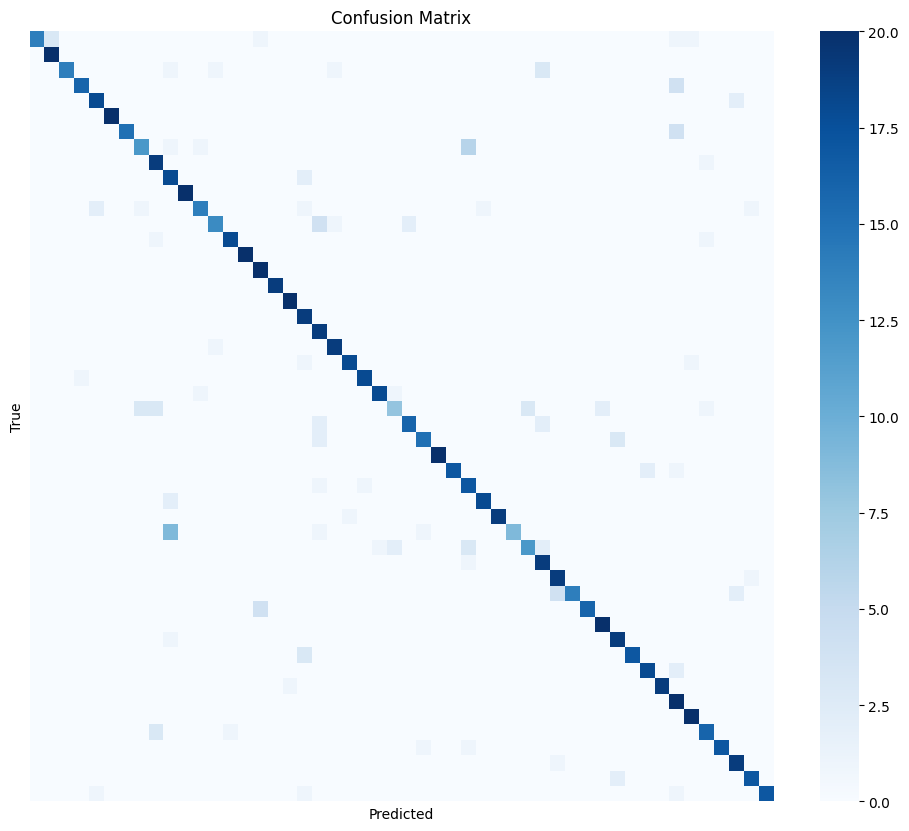

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

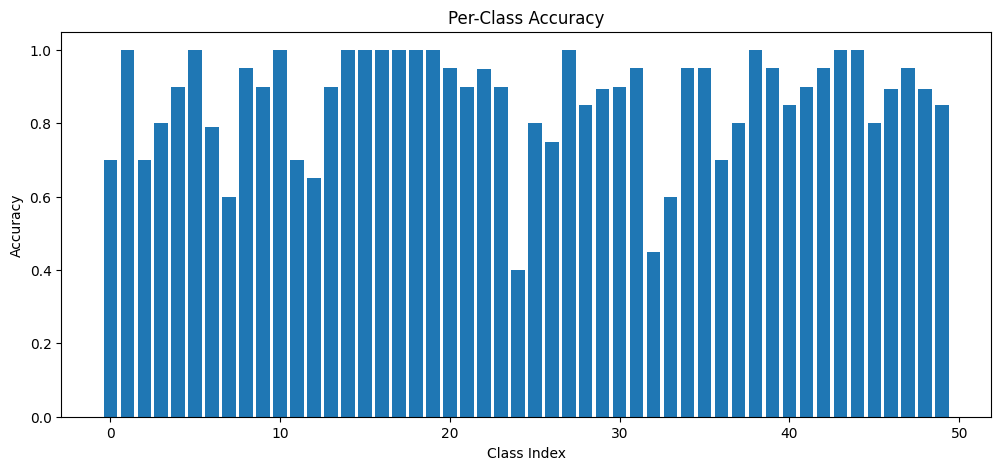

In [6]:
plt.figure(figsize=(12, 5))
plt.bar(range(len(per_class_acc)), per_class_acc)
plt.title("Per-Class Accuracy")
plt.xlabel("Class Index")
plt.ylabel("Accuracy")
plt.show()

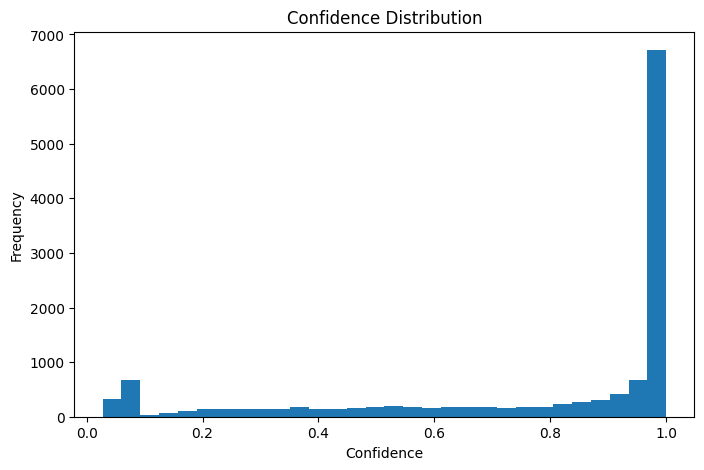

In [7]:
plt.figure(figsize=(8,5))
plt.hist(confidences, bins=30)
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

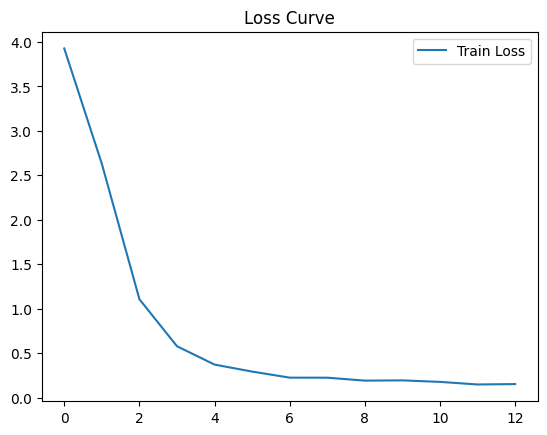

In [8]:
plt.plot(history["train_loss"], label="Train Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

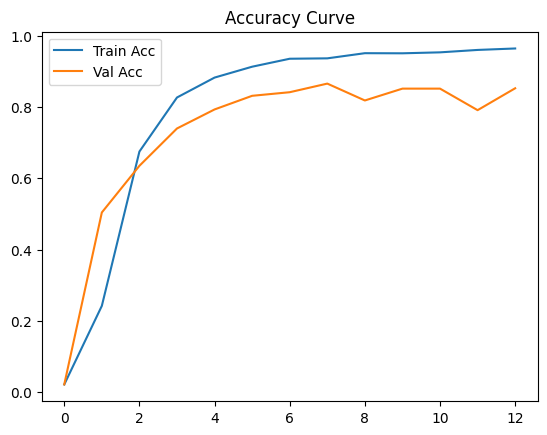

In [9]:
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

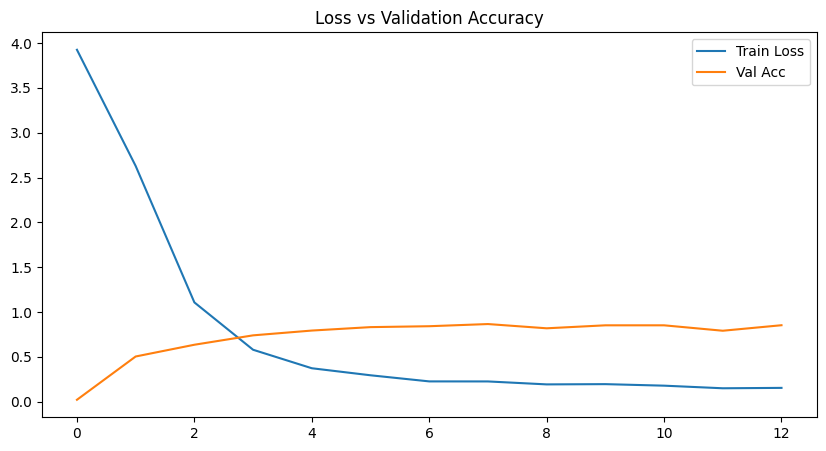

In [10]:
plt.figure(figsize=(10,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_acc"], label="Val Acc")

plt.title("Loss vs Validation Accuracy")
plt.legend()
plt.show()

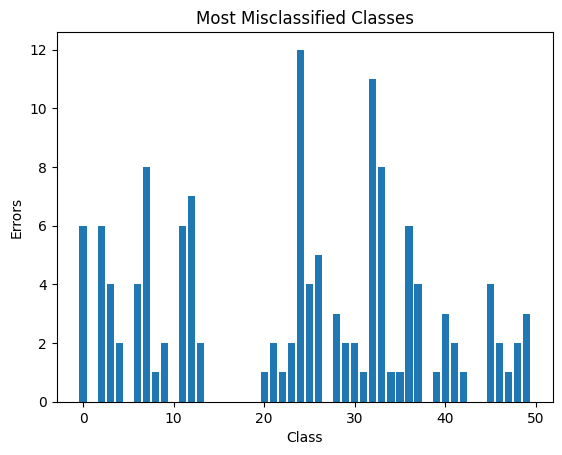

In [11]:
errors = best_preds != best_labels

error_classes = best_labels[errors]

unique, counts = np.unique(error_classes, return_counts=True)

plt.bar(unique, counts)
plt.title("Most Misclassified Classes")
plt.xlabel("Class")
plt.ylabel("Errors")
plt.show()

In [12]:
for i in range(5):
    print(sample_predictions[i])

{'true': 2, 'pred': 33, 'top5': [33, 12, 26, 16, 24]}
{'true': 14, 'pred': 31, 'top5': [31, 35, 5, 8, 1]}
{'true': 22, 'pred': 31, 'top5': [31, 6, 35, 5, 8]}
{'true': 24, 'pred': 31, 'top5': [31, 6, 8, 35, 5]}
{'true': 31, 'pred': 31, 'top5': [31, 6, 35, 8, 5]}
